# Bootstrap
Configuring parameters, loading libraries and datasets.

In [195]:
import sys, os
# This line allows us to import from the parent directory, which is where the 'src' folder is located.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# These lines enable automatic reloading of modules in Jupyter, so that changes to the code are reflected without needing to restart the kernel.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Libraries
External

In [196]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import math as math
from scipy.stats import norm

Project libraries

In [197]:
from src.utils import Config
from src.utils import clip_outliers
from src.plots import PlotGrid, Histogram, CorrelationHeatmap, FrequencyPie, ScatterPlot, CrossTabBar, SplitViolin, TimeSeriesPlot

## Configuration
Set here general paramenters

In [198]:
config = Config({
    'datasets_path': '../data/aggregated/',
    'central_tendency_measure': 'mean',
})

## Loading Datasets

In [199]:
users = pd.read_csv(f"{config.datasets_path}/users.csv")
# Convert Users date columns to datetime format
cols_to_datetime = ['birthdate', 'sign_up_date']
users[cols_to_datetime] = users[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

In [200]:
flights = pd.read_csv(f"{config.datasets_path}/flights.csv")
# Convert Flights date columns to datetime format
cols_to_datetime = ['departure_time', 'return_time']
flights[cols_to_datetime] = flights[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

In [201]:
hotels = pd.read_csv(f"{config.datasets_path}/hotels.csv")
# Convert Hotels date columns to datetime format
cols_to_datetime = ['check_in_time', 'check_out_time']
hotels[cols_to_datetime] = hotels[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

In [202]:
sessions = pd.read_csv(f"{config.datasets_path}/sessions.csv")
# Convert Sessions date columns to datetime format
cols_to_datetime = ['session_start', 'session_end']
sessions[cols_to_datetime] = sessions[cols_to_datetime].apply(pd.to_datetime, errors='coerce')

# Exploratory Data Analysis

In [203]:
df_merged = sessions.merge(users, on='user_id', how='left') \
                         .merge(flights, on='trip_id', how='left') \
                         .merge(hotels, on='trip_id', how='left')

## Distribuitions
In this sections we will observe some feature's distrubuitions, to check if we find something interesting or abnormal with them.

In [204]:
ctm = config.central_tendency_measure.title()

### Users

* = with outliers clipped above 3 standard deviations from the mean


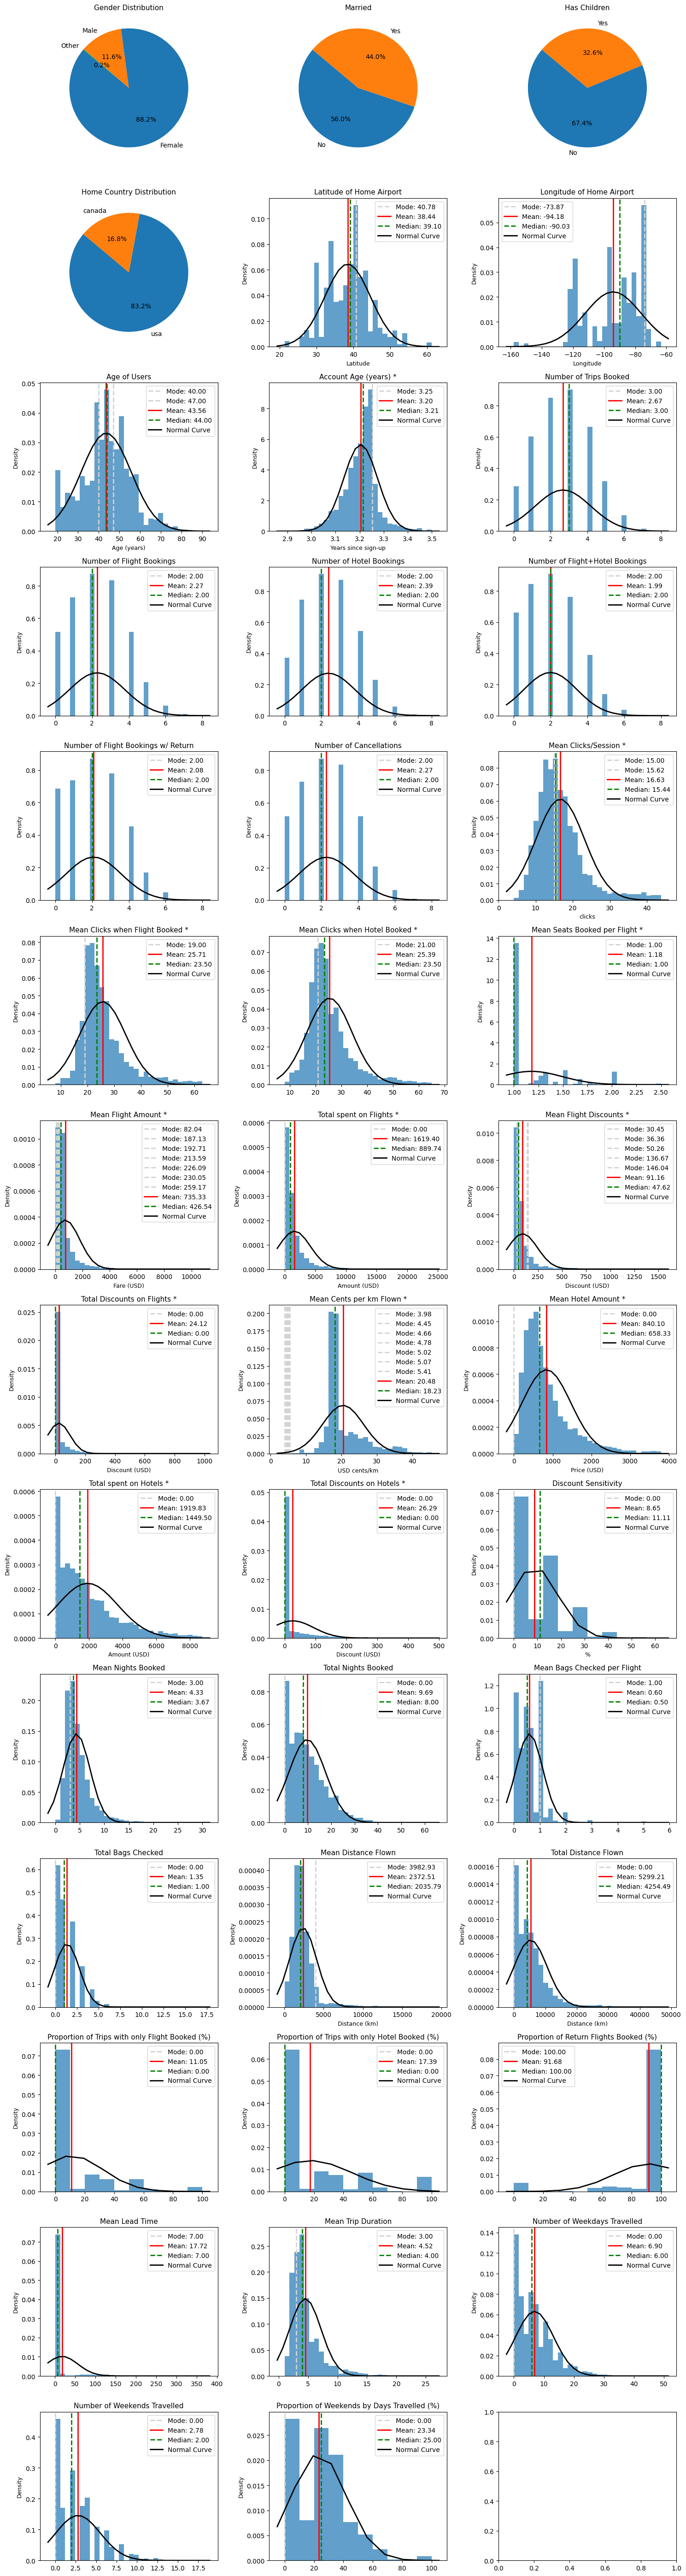

In [205]:
print("* = with outliers clipped above 3 standard deviations from the mean")
PlotGrid(n_cols=3).plot_all([
  FrequencyPie(users.gender, 'Gender Distribution', {'F': 'Female', 'M': 'Male', 'O': 'Other'}),
  FrequencyPie(users.married.astype(int), 'Married', {False: 'No', True: 'Yes'}),
  FrequencyPie(users.has_children.astype(int), 'Has Children', {False: 'No', True: 'Yes'}),
  FrequencyPie(users.home_country, 'Home Country Distribution'),
  Histogram(users.home_airport_lat, 'Latitude of Home Airport', 'Latitude'),
  Histogram(users.home_airport_lon, 'Longitude of Home Airport', 'Longitude'),
  Histogram(users.age, 'Age of Users', 'Age (years)'),
  Histogram(clip_outliers(users.account_age), 'Account Age (years) *', 'Years since sign-up'),
  Histogram(users.total_trips, 'Number of Trips Booked'),
  Histogram(users.flight_bookings, 'Number of Flight Bookings'),
  Histogram(users.hotel_bookings, 'Number of Hotel Bookings'),
  Histogram(users.combo_bookings, 'Number of Flight+Hotel Bookings'),
  Histogram(users.return_flight_bookings, 'Number of Flight Bookings w/ Return'),
  Histogram(users.flight_bookings, 'Number of Cancellations'),
  Histogram(clip_outliers(users.avg_page_clicks), f'{ctm} Clicks/Session *', 'clicks'),
  Histogram(clip_outliers(users.avg_page_clicks_flight_booked), f'{ctm} Clicks when Flight Booked *'),
  Histogram(clip_outliers(users.avg_page_clicks_hotel_booked), f'{ctm} Clicks when Hotel Booked *'),
  Histogram(clip_outliers(users.avg_seats_booked), f'{ctm} Seats Booked per Flight *'),
  Histogram(clip_outliers(users.avg_flight_amount), f'{ctm} Flight Amount *', 'Fare (USD)'),
  Histogram(clip_outliers(users.total_flight_amount), 'Total spent on Flights *', 'Amount (USD)'),
  Histogram(clip_outliers(users.avg_flight_discount), f'{ctm} Flight Discounts *', 'Discount (USD)'),
  Histogram(clip_outliers(users.total_flight_discount), 'Total Discounts on Flights *', 'Discount (USD)'),
  Histogram(clip_outliers(users.avg_cents_km_flown), f'{ctm} Cents per km Flown *', 'USD cents/km'),
  Histogram(clip_outliers(users.avg_hotel_amount), f'{ctm} Hotel Amount *', 'Price (USD)'),
  Histogram(clip_outliers(users.total_hotel_amount), 'Total spent on Hotels *', 'Amount (USD)'),
  Histogram(clip_outliers(users.total_hotel_discount), 'Total Discounts on Hotels *', 'Discount (USD)'),
  Histogram(100 * users.discount_sensitivity, 'Discount Sensitivity', '%', bins=10),
  Histogram(users.avg_hotel_nights, f'{ctm} Nights Booked'),
  Histogram(users.total_hotel_nights, 'Total Nights Booked'),
  Histogram(users.avg_checked_bags, f'{ctm} Bags Checked per Flight'),
  Histogram(users.total_checked_bags, 'Total Bags Checked'),
  Histogram(users.avg_distance_flown, f'{ctm} Distance Flown', 'Distance (km)'),
  Histogram(users.total_distance_flown, 'Total Distance Flown', 'Distance (km)'),
  Histogram(100 * users.pct_only_flight_booked, 'Proportion of Trips with only Flight Booked (%)', bins=10),
  Histogram(100 * users.pct_only_hotel_booked, 'Proportion of Trips with only Hotel Booked (%)', bins=10),
  Histogram(100 * users.pct_return_flight_booked, 'Proportion of Return Flights Booked (%)', bins=10),
  Histogram(users.avg_trip_lead_time, f'{ctm} Lead Time'),
  Histogram(users.avg_trip_duration, f'{ctm} Trip Duration'),
  Histogram(users.weekdays_travelled, 'Number of Weekdays Travelled'),
  Histogram(users.weekends_travelled, 'Number of Weekends Travelled'),
  Histogram(100 * users.weekends_ratio, 'Proportion of Weekends by Days Travelled (%)', bins=10),
])

### Sessions

* = with outliers clipped above 3 standard deviations from the mean


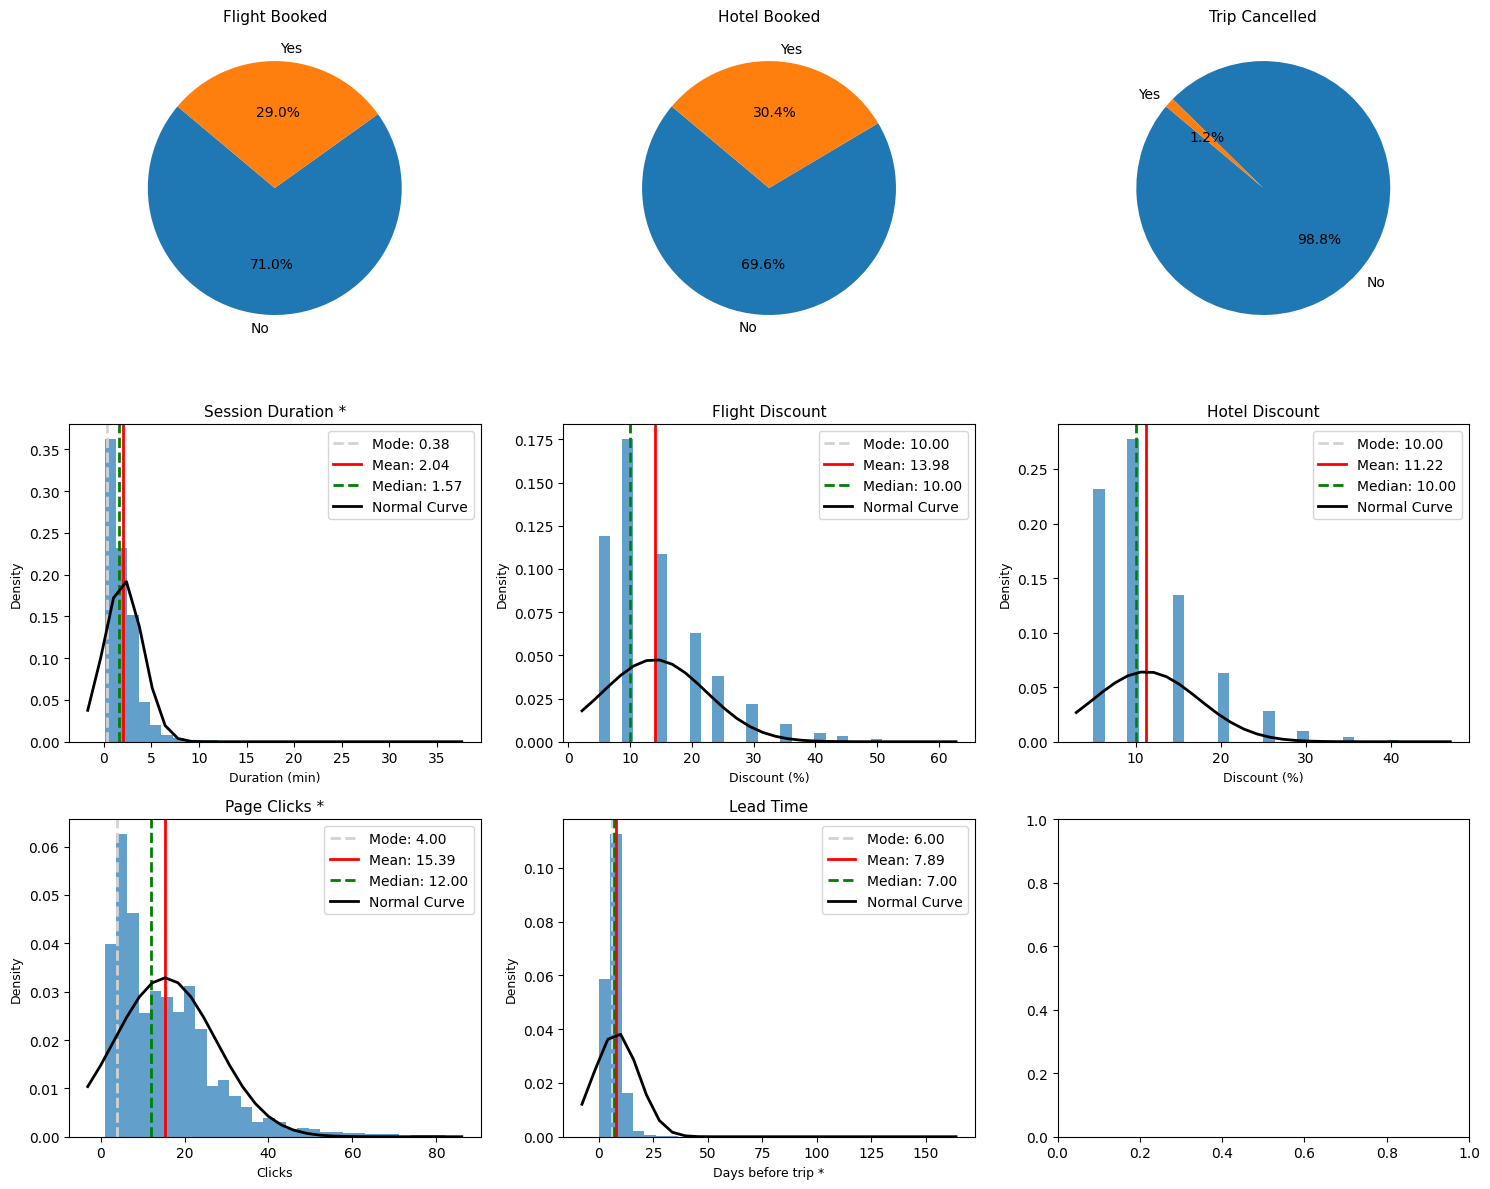

In [206]:
print("* = with outliers clipped above 3 standard deviations from the mean")
PlotGrid(n_cols=3).plot_all([
  FrequencyPie(sessions.flight_booked, 'Flight Booked', {False: 'No', True: 'Yes'}),
  FrequencyPie(sessions.hotel_booked, 'Hotel Booked', {False: 'No', True: 'Yes'}),
  FrequencyPie(sessions.cancellation, 'Trip Cancelled', {False: 'No', True: 'Yes'}),
  Histogram(clip_outliers(sessions.session_duration), 'Session Duration *', 'Duration (min)'),
  Histogram(100*sessions.flight_discount_amount, 'Flight Discount', 'Discount (%)'),
  Histogram(100*sessions.hotel_discount_amount, 'Hotel Discount', 'Discount (%)'),
  Histogram(clip_outliers(sessions.page_clicks), 'Page Clicks *', 'Clicks'),
  Histogram(clip_outliers(sessions.lead_time), 'Lead Time', 'Days before trip *'),
])

### Flights

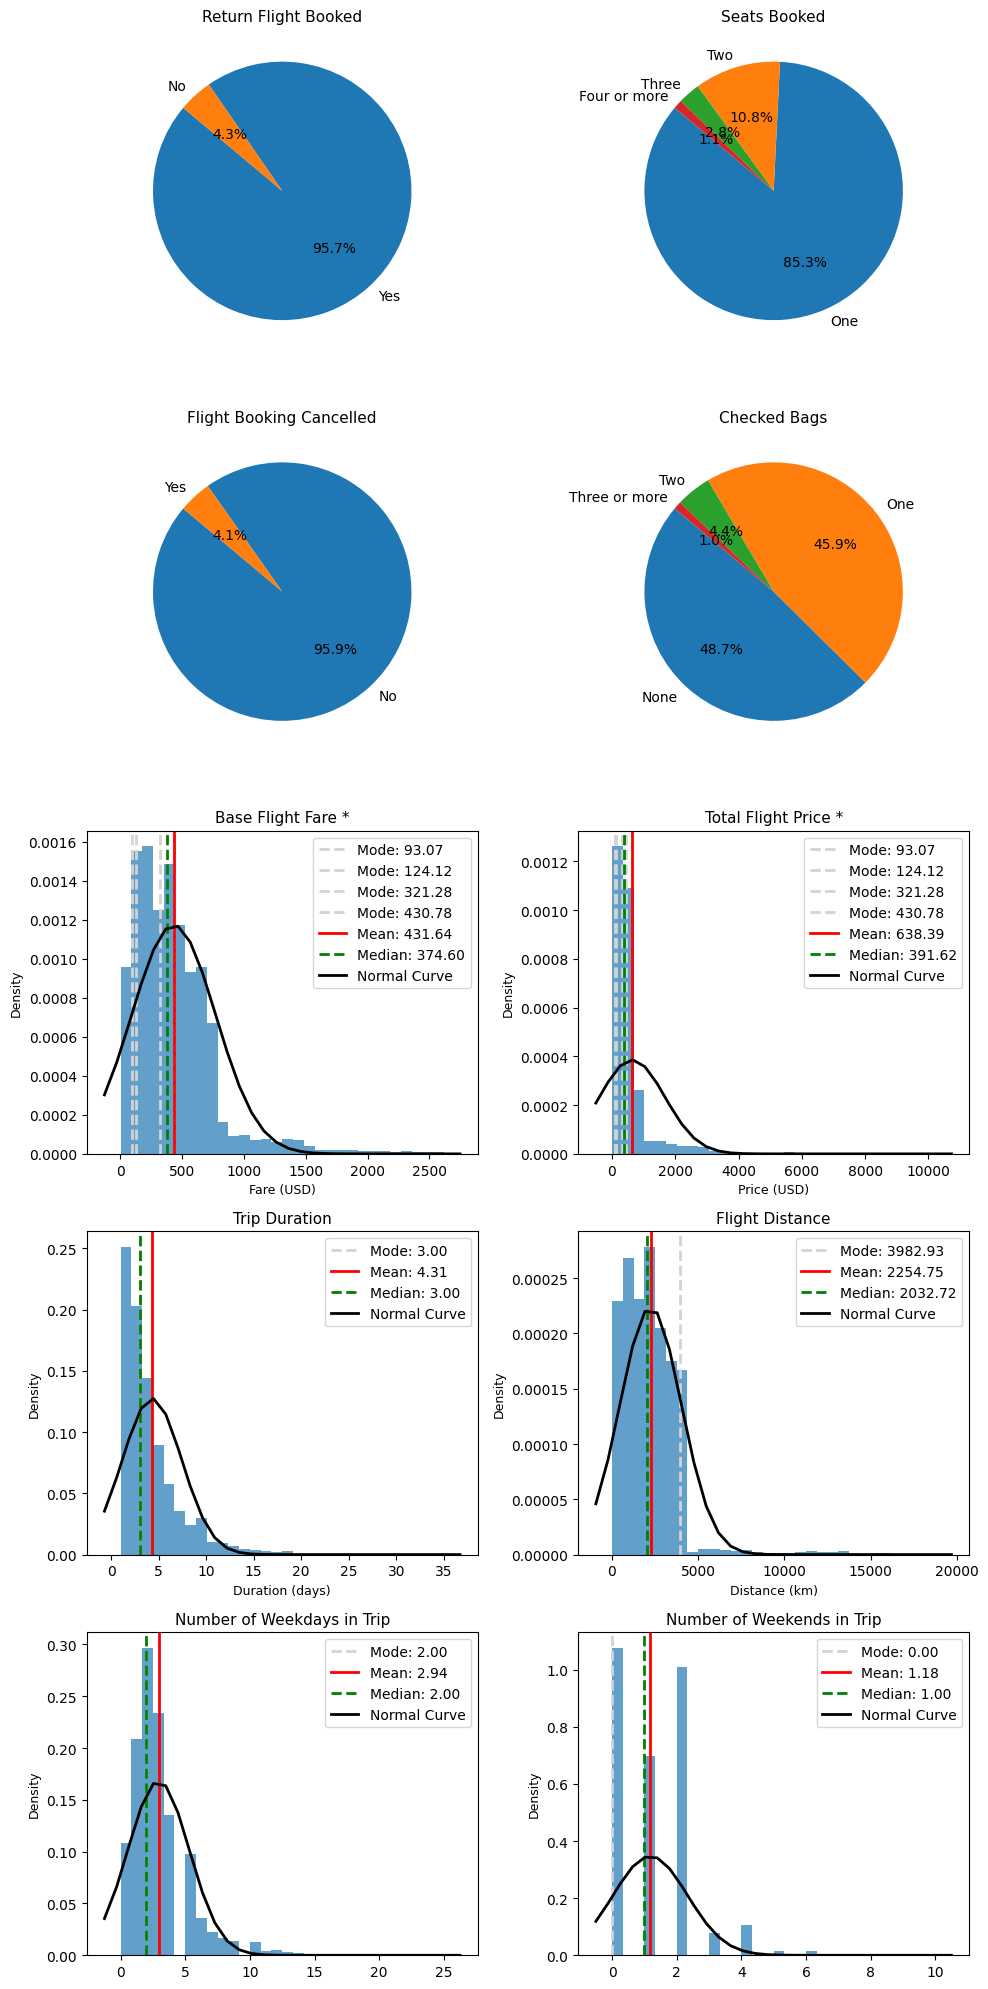

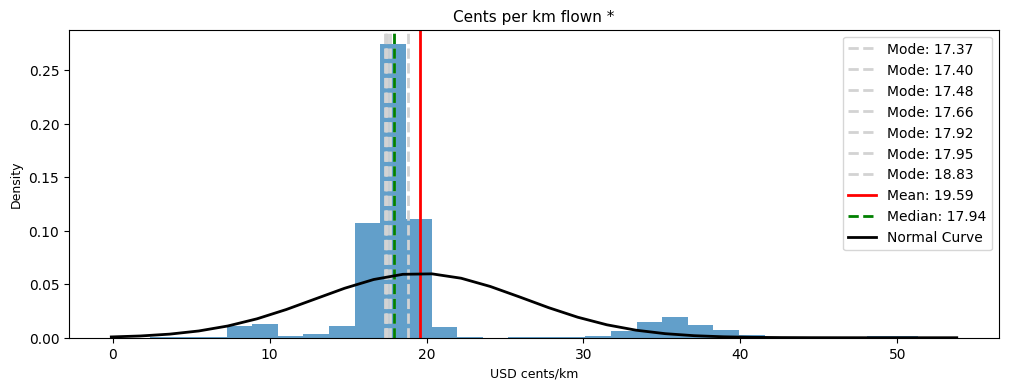

In [207]:
flight_seats = flights.seats.copy()  # Create a copy of the 'seats' column to avoid modifying the original DataFrame
flight_seats.loc[flight_seats > 4] = 4  # Cap the values at 4 for better visualization

flight_bags = flights.checked_bags.copy()  # Create a copy of the 'checked_bags' column to avoid modifying the original DataFrame
flight_bags.loc[flight_bags > 3] = 3  # Cap the values at 3 for better visualization

PlotGrid(n_cols=2).plot_all([
    FrequencyPie(flights.return_flight_booked, 'Return Flight Booked', {False: 'No', True: 'Yes'}),
    FrequencyPie(flight_seats, 'Seats Booked', {1: 'One', 2: 'Two', 3: 'Three', 4: 'Four or more'}),
    FrequencyPie(flights.cancelled, 'Flight Booking Cancelled', {False: 'No', True: 'Yes'}),
    FrequencyPie(flight_bags, 'Checked Bags', {0: 'None', 1: 'One', 2: 'Two', 3: 'Three or more'}),
    Histogram(clip_outliers(flights.base_fare_usd), 'Base Flight Fare *', 'Fare (USD)'),
    Histogram(clip_outliers(flights.total_flight_price), 'Total Flight Price *', 'Price (USD)'),
    Histogram(flights.trip_duration, 'Trip Duration', 'Duration (days)'),
    Histogram(flights.flight_distance_km, 'Flight Distance', 'Distance (km)'),
    Histogram(flights.weekdays_in_trip, 'Number of Weekdays in Trip'),
    Histogram(flights.weekends_in_trip, 'Number of Weekends in Trip'),
])

Histogram(clip_outliers(flights.cents_per_km_flown), 'Cents per km flown *', 'USD cents/km', figsize=(12, 4)).plot()

### Hotels

* = with outliers clipped above 3 standard deviations from the mean


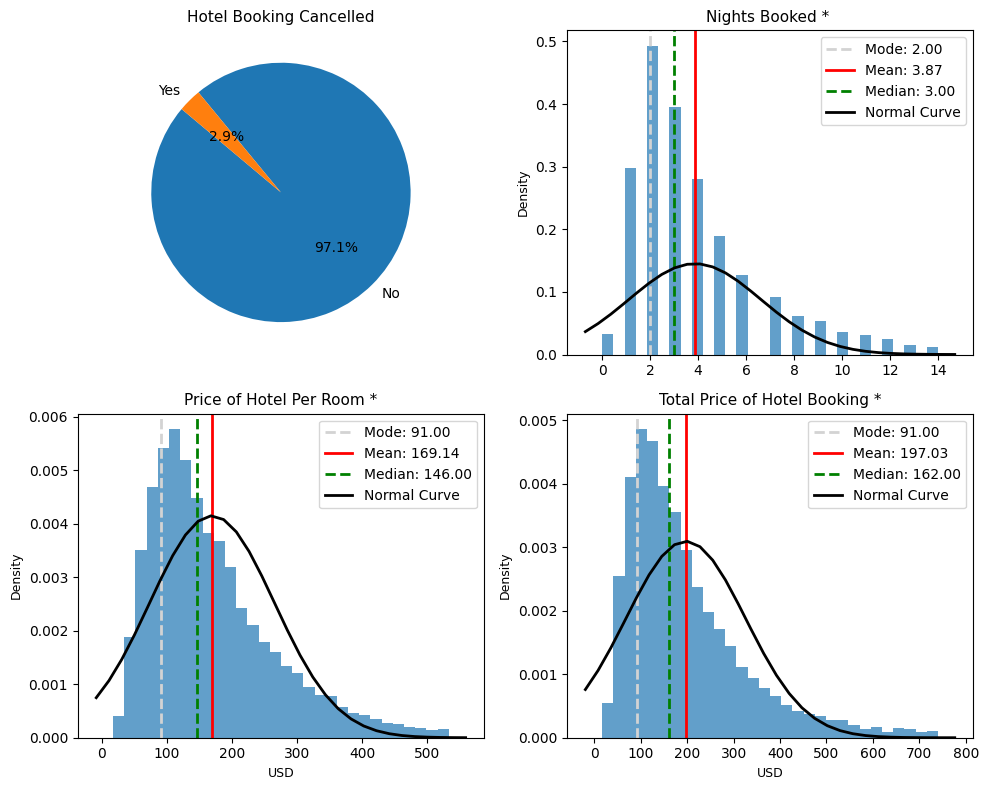

In [208]:
print("* = with outliers clipped above 3 standard deviations from the mean")
PlotGrid(n_cols=2).plot_all([
    FrequencyPie(hotels.cancelled, 'Hotel Booking Cancelled', {False: 'No', True: 'Yes'}),
    Histogram(clip_outliers(hotels.nights), 'Nights Booked * '),
    Histogram(clip_outliers(hotels.hotel_per_room_usd), 'Price of Hotel Per Room *', 'USD'),
    Histogram(clip_outliers(hotels.total_hotel_price), 'Total Price of Hotel Booking *', 'USD'),
])

> `base_fare_usd` have a very right-skewed distribuition, while in `cents_per_km_flown` has clearly 4 distruitions: under 10, between 10 and 25, between 30 and 45 and above 45.

## Correlation Analysis of Numerical Features

Let's investigate the correlation between various numerical features to understand their relationships. A heatmap can visually represent these correlations.

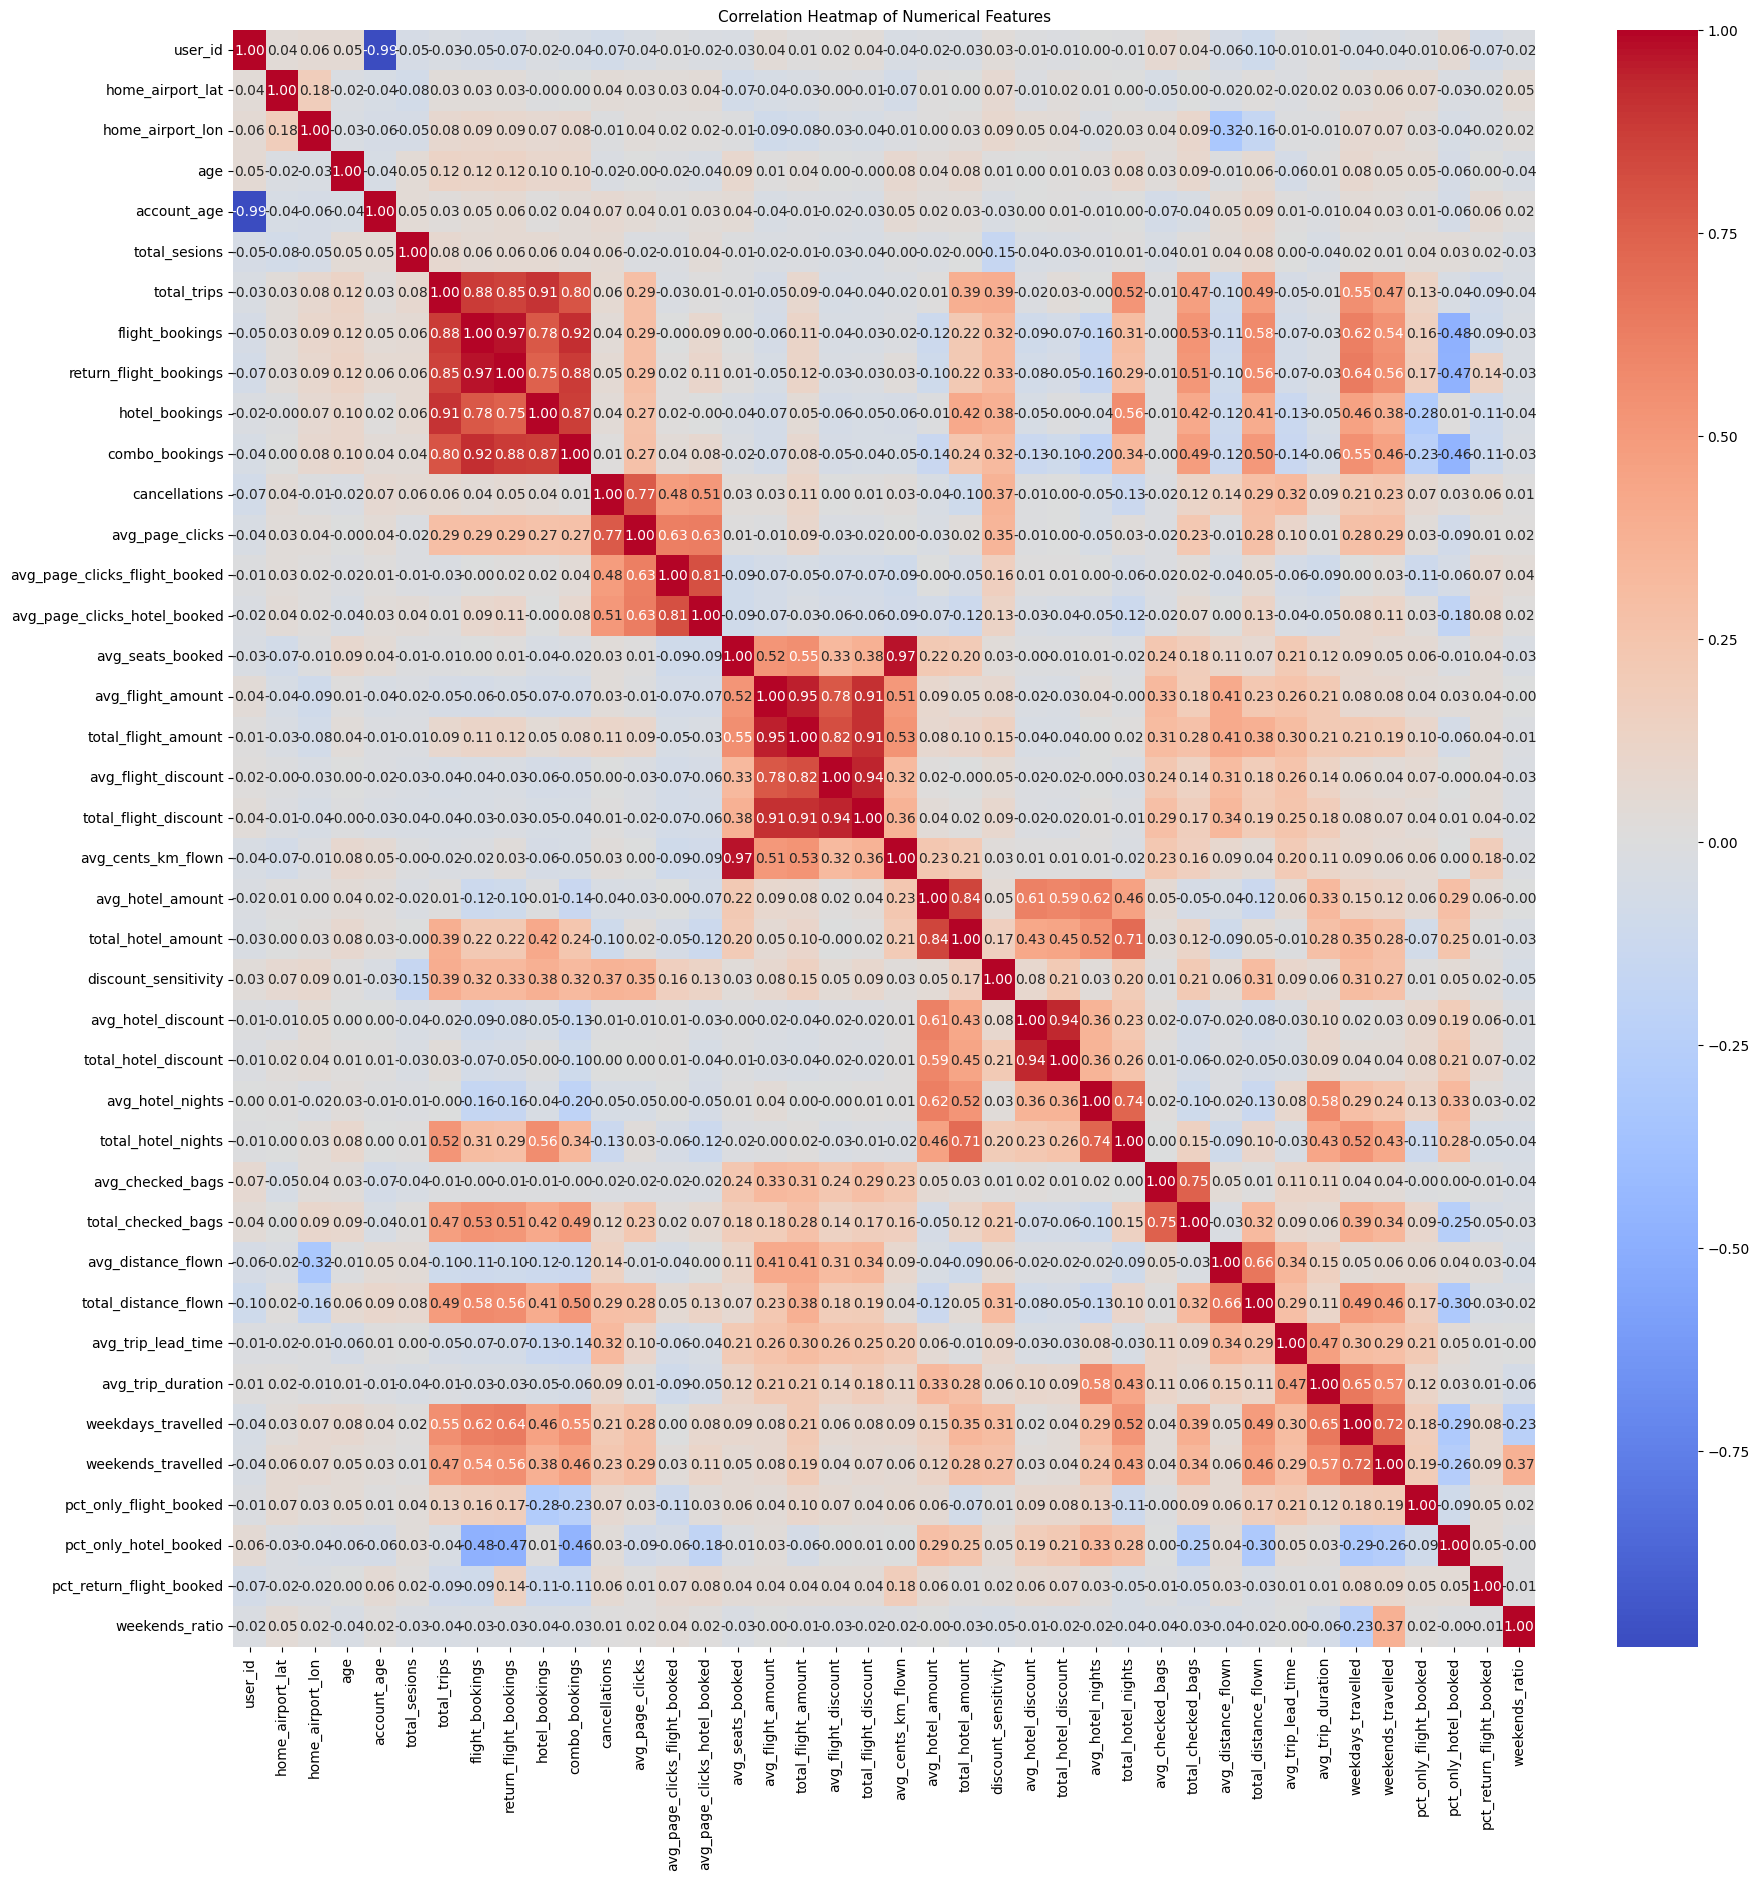

In [209]:
# Select relevant numerical columns from df_merged for correlation analysis
numeric_features = users.select_dtypes(include=[np.number]).columns.tolist()

CorrelationHeatmap(
    df = df_merged, 
    columns = numeric_features, 
    title = 'Correlation Heatmap of Numerical Features',
).plot()

* `session_duration` and `page_clicks` are perfectly correlated, show the rate of page clicks is constant.
* There's a strong correlation between `flight_distance_km` and `base_fare_usd`, which makes sense, as longer flights are expected to cost more.
* There's a mild correlation between `lead_time` and `flight_distance_km`, suggesting that users tend to book longer flights in advance.
* There's a mild correlation between `base_fare_usd` and `lead_time`, showing that early planners tend to pay more than last-minute bookings.

The other strong correlations are results of a clear relationship between features, like the averages and totals of discounts and amounts, and, for instance, the hotel amount and number of nights, or flight amount and number of seats.

In the cell below we sort all numeric features by absolute corelations.
A lower max absolute correlation signals that the feature has more "essential" information, a higher one means more redundancy of its information, contained in other features. Where `0` means nothing of its information is present in any of the features, while `1` means all of its information is present in one or more features, and, therefore, the feature is completely redundant.
This is specially helpful when deciding upon **reducing the dimention** of the dataset, if needed. Features with higher redundancy, max absolute correlation, are better candidates to be removed.

In [210]:
# Calculate the correlation matrix
correlation_matrix = users[numeric_features].corr()
# Remove all correlations from diagonal (self-correlations)
np.fill_diagonal(correlation_matrix.values, np.nan)
# Calculate the maximum of absolute correlations for each feature
max_correlation = correlation_matrix.abs().max()
# Sort features by maximum correlation
sorted_features = max_correlation.sort_values(ascending=False).index.tolist()
print("Features sorted by redundancy, in descending order:")
for feature in sorted_features:
    print(feature, ' = ', max_correlation[feature])

Features sorted by redundancy, in descending order:
user_id  =  0.9775255234422339
account_age  =  0.9775255234422339
avg_seats_booked  =  0.9626811954720881
avg_cents_km_flown  =  0.9626811954720881
total_hotel_discount  =  0.9573625143829668
avg_hotel_discount  =  0.9573625143829668
avg_flight_amount  =  0.9467219691895146
total_flight_amount  =  0.9467219691895146
avg_flight_discount  =  0.943585401324359
total_flight_discount  =  0.943585401324359
total_trips  =  0.9370312795806555
hotel_bookings  =  0.9370312795806555
flight_bookings  =  0.9363359071560671
combo_bookings  =  0.9363359071560671
return_flight_bookings  =  0.9117360957189656
avg_page_clicks_flight_booked  =  0.8404019787542268
avg_page_clicks_hotel_booked  =  0.8404019787542268
weekends_travelled  =  0.8331818727317759
weekdays_travelled  =  0.8331818727317759
avg_hotel_amount  =  0.756585889002343
total_hotel_amount  =  0.756585889002343
total_hotel_nights  =  0.7429114777618766
avg_checked_bags  =  0.74236760371419

## Conversion Analysis
What drives users to actually "pull the trigger"?

### The "Discount Hook"
* Do discounts increase booking rate?
* Is there a "magic number" where conversion rates spike significantly?

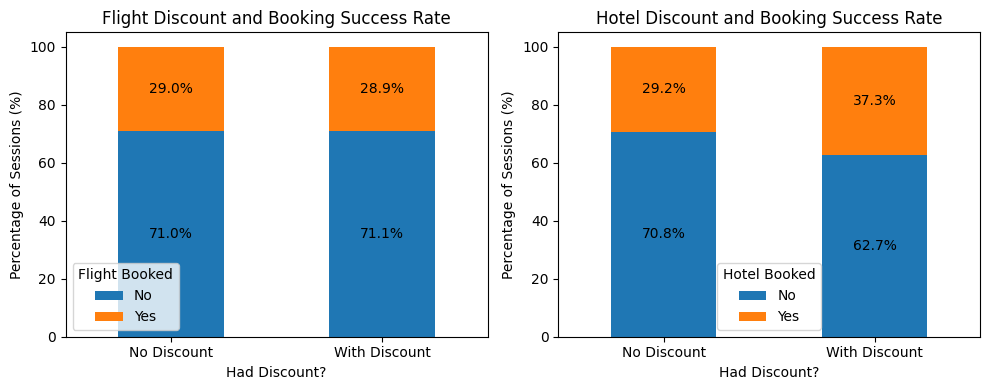

In [211]:
PlotGrid(n_cols=2).plot_all([
    CrossTabBar(
        x_data = sessions[f'{booking}_discount'], 
        y_data = sessions[f'{booking}_booked'], 
        title = f'{booking.capitalize()} Discount and Booking Success Rate',
        x_label = 'Had Discount?',
        y_label = 'Percentage of Sessions (%)',
        x_value_labels = {False: 'No Discount', True: 'With Discount'},
        y_value_labels = {False: 'No', True: 'Yes'},
        legend_title = f'{booking.capitalize()} Booked'
    ) for booking in ['flight', 'hotel']
])

> We can observe that discounts are taken sensibly more for Hotel bookings than for Flights

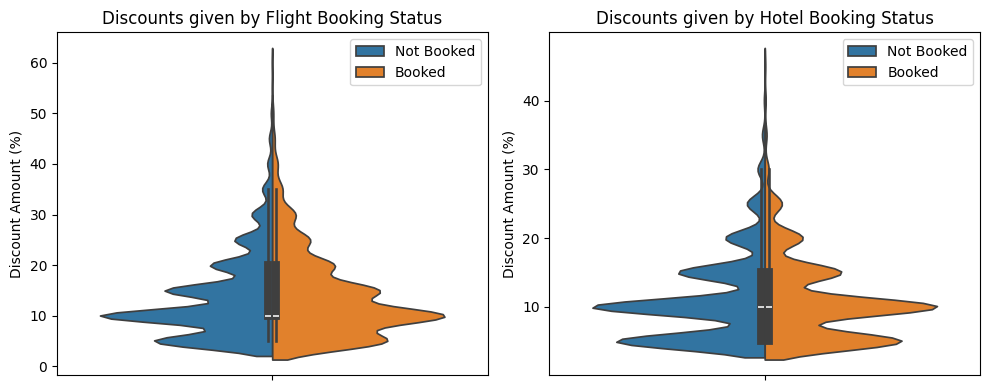

In [212]:
PlotGrid(n_cols=2).plot_all([
    SplitViolin(
        y_data = 100*sessions.flight_discount_amount, 
        split_data = sessions.flight_booked, 
        title = 'Discounts given by Flight Booking Status',
        y_label = 'Discount Amount (%)',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    ),
    SplitViolin(
        y_data = 100*sessions.hotel_discount_amount, 
        split_data = sessions.hotel_booked, 
        title = 'Discounts given by Hotel Booking Status',
        y_label = 'Discount Amount (%)',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    )
])

> We observe no significant difference in discount distribuition for booked and not booked flights and hotels.
> We can conclude that there is no specific discount amount that makes bookings more likely

### Friction vs. Engagement
* Does a high number of clicks indicate high intent, or does it suggest the user is frustrated and can't find what they want?

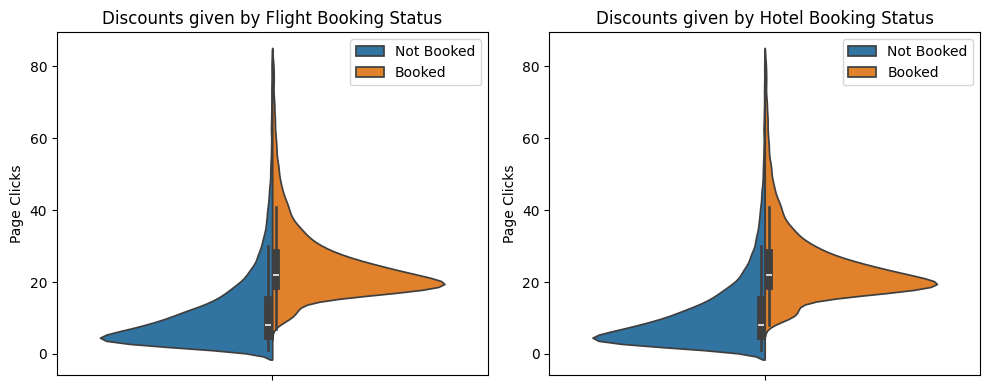

In [213]:
PlotGrid(n_cols=2).plot_all([
    SplitViolin(
        y_data = clip_outliers(sessions.page_clicks), 
        split_data = sessions.flight_booked, 
        title = 'Discounts given by Flight Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    ),
    SplitViolin(
        y_data = clip_outliers(sessions.page_clicks),
        split_data = sessions.hotel_booked, 
        title = 'Discounts given by Hotel Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    )
])

> We can see that sessions with booking have around 15 clicks more than sessions without, both for hotels and flights.

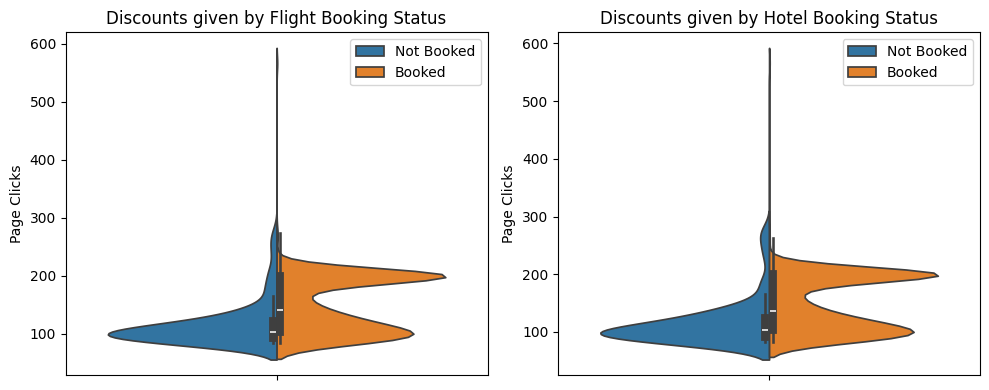

In [214]:
# Funny anomally
# Clipping everything but the outliers...
df_clipped = sessions[
    (sessions['page_clicks'] - sessions['page_clicks'].mean()).abs()
    > 3 * sessions['page_clicks'].std()
]

PlotGrid(n_cols=2).plot_all([
    SplitViolin(
        y_data = df_clipped.page_clicks, 
        split_data = df_clipped.flight_booked, 
        title = 'Discounts given by Flight Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    ),
    SplitViolin(
        y_data = df_clipped.page_clicks,
        split_data = df_clipped.hotel_booked, 
        title = 'Discounts given by Hotel Booking Status',
        y_label = 'Page Clicks',
        split_labels = {False: 'Not Booked', True: 'Booked'}
    )
])

> We observe a spike around 200 clicks, that might need some further investigation. It can be, for example, users ta look and look, try different dates or add-ons, but in the end they book it.

### The Multi-Product Lift
* Are users who book a flight more likely to book a hotel in the same trip?

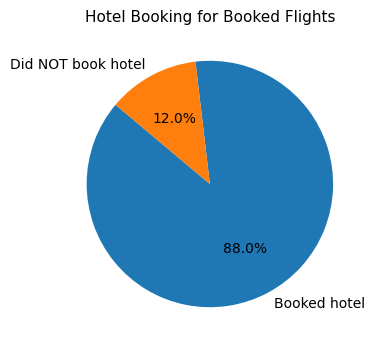

In [215]:
FrequencyPie(
    data = sessions[sessions.flight_booked].hotel_booked, 
    title = 'Hotel Booking for Booked Flights',
    labels = {True:'Booked hotel', False:'Did NOT book hotel'},
).plot()

> The vast majority of users that book a flight also book a hotel, thefore offering a combo might be interesting to most customers

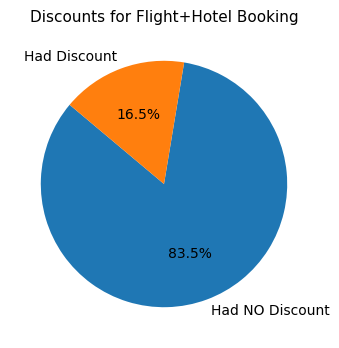

In [216]:
FrequencyPie(
    data = sessions[sessions.flight_booked & sessions.hotel_booked].hotel_discount, 
    title = 'Discounts for Flight+Hotel Booking',
    labels = {True: 'Had Discount', False: 'Had NO Discount'}
).plot()

> So, when booking flights, most customers also book hotels, even when no discount is offered for the hotel booking

## Pricing and Cancellation Patterns

### Cancelation Profile
* Do discounts influence the cancellation rate?
* Are certain `trip_airline` carriers or `hotel_name` chains associated with higher cancellation rates? Is it a user trait or a service provider issue?

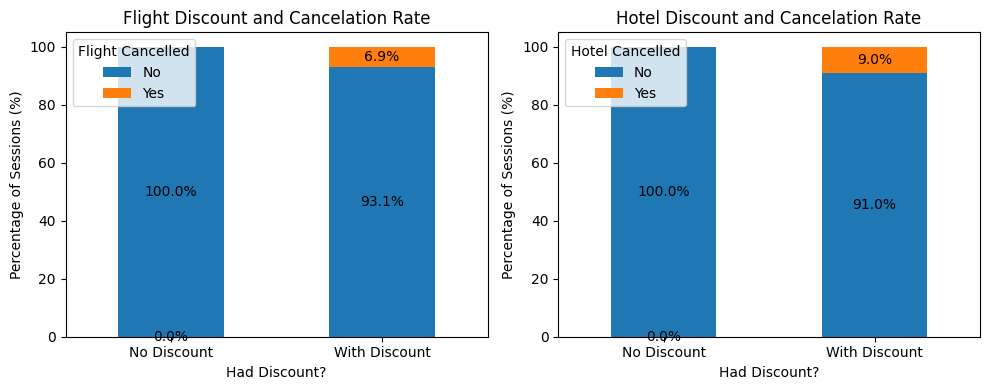

In [217]:
PlotGrid(n_cols=2).plot_all([
    CrossTabBar(
        x_data = sessions[f'{booking}_discount'], 
        y_data = sessions['cancellation'], 
        title = f'{booking.capitalize()} Discount and Cancelation Rate',
        x_label = 'Had Discount?',
        y_label = 'Percentage of Sessions (%)',
        x_value_labels = {False: 'No Discount', True: 'With Discount'},
        y_value_labels = {False: 'No', True: 'Yes'},
        legend_title = f'{booking.capitalize()} Cancelled'
    ) 
    for booking in ['flight', 'hotel']
])

> Strangly, it seems discounts have worse results than no discounts, when it comes to cancellation rate

#### Airlines
Airlines with more than 5 bookings and cancellation rate above 30%

In [218]:
airline_stats = df_merged.groupby('trip_airline').agg(
    total_bookings=('flight_booked', 'sum'),
    total_cancellations=('cancellation', 'sum')
).reset_index()

airline_stats['cancellation_rate'] = (
    100 * airline_stats['total_cancellations'] / airline_stats['total_bookings']
).round(2)

airline_stats[(airline_stats.total_bookings > 5) & (airline_stats.cancellation_rate > 30)].sort_values(by='cancellation_rate', ascending=False)

,trip_airline,total_bookings,total_cancellations,cancellation_rate
155,Transavia Holland,6,3,50.00
79,Germanwings,7,3,42.86
171,easyJet,12,5,41.67
1,Aegean Airlines,6,2,33.33
56,Condor Flugdienst,6,2,33.33
65,Egyptair,6,2,33.33
116,Overland Airways,6,2,33.33
154,Transaero Airlines,6,2,33.33
54,China Southern Airlines,13,4,30.77


> We can see many airlines with high cancellation rates, especially "Air Serbia", "Shanghai Airlines" and "SunExpress"

#### Hotels
Hotels with more than 3 bookings and cancellation rate above 30%

In [219]:
hotel_stats = df_merged.groupby('hotel_name').agg(
    total_bookings=('hotel_booked', 'sum'),
    total_cancellations=('cancellation', 'sum')
).reset_index()

# 3. Calculate a Cancellation Rate for better context
hotel_stats['cancellation_rate'] = (
    hotel_stats['total_cancellations'] / hotel_stats['total_bookings'] * 100
).round(2)

hotel_stats[(hotel_stats.total_bookings > 3) & (hotel_stats.cancellation_rate > 30)].sort_values(by='cancellation_rate', ascending=False)

,hotel_name,total_bookings,total_cancellations,cancellation_rate
137,Banyan Tree - singapore,4,2,50.0
737,Radisson - london,4,2,50.0
932,Wyndham - macau,4,2,50.0
670,NH Hotel - bangkok,5,2,40.0


> We observe many hotels with high cancelation rates, especially "Crowne Plaza - antalya"

### Lead Time Analysis
* Do "last-minute" bookers pay significantly more `base_fare_usd`, and do they use more discounts?
* Do discounts affect cancellation rate?

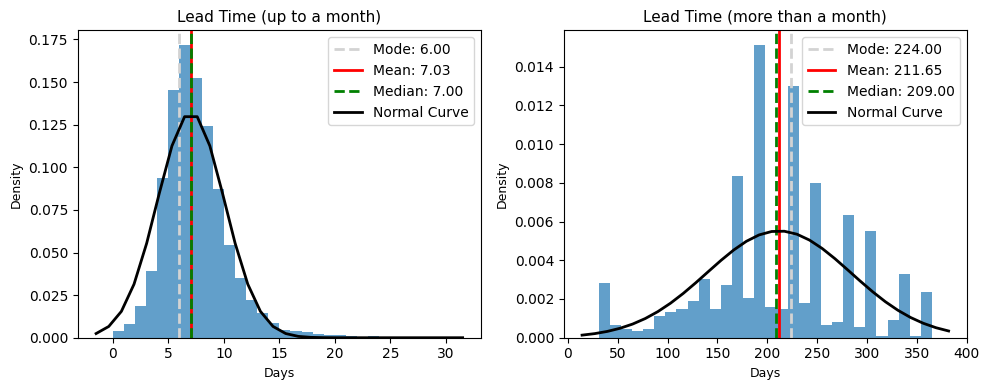

In [220]:
PlotGrid(n_cols=2).plot_all([
    Histogram(df_merged[df_merged.lead_time <= 30].lead_time, 'Lead Time (up to a month)', 'Days'),
    Histogram(df_merged[df_merged.lead_time > 30].lead_time, 'Lead Time (more than a month)', 'Days')
])

> We can see there are two separate distribuitions for lead time: one between 0 and 20 days before trip, and another between 40 and 400 days.

In [221]:
df_short_planners = df_merged[df_merged.lead_time <= 30]
df_long_planners = df_merged[df_merged.lead_time > 30]

def plot_leadtime_scatter(column, y_label, unit):
  PlotGrid(n_cols=2, cell_size=(6, 4)).plot_all([
      ScatterPlot(
        x = df_short_planners.lead_time, y = df_short_planners[column], 
        title = y_label + ' for bookings up to a month in advance',
        x_label = 'Lead Time', y_label = y_label,
        x_unit = 'days', y_unit = unit
      ),
      ScatterPlot(
        x = df_long_planners.lead_time, y = df_long_planners[column],
        title = y_label + ' for bookings longer than a month in advance',
        x_label = 'Lead Time', y_label = y_label,
        x_unit = 'days', y_unit = unit
      )
  ])

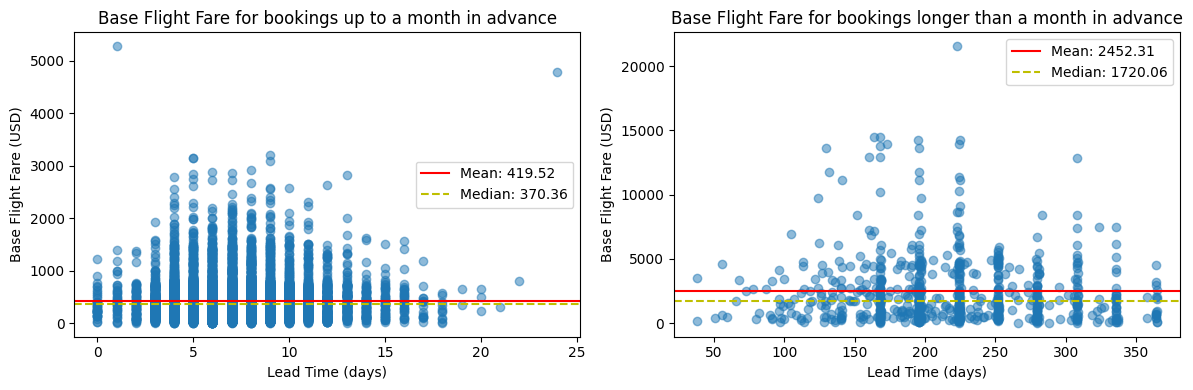

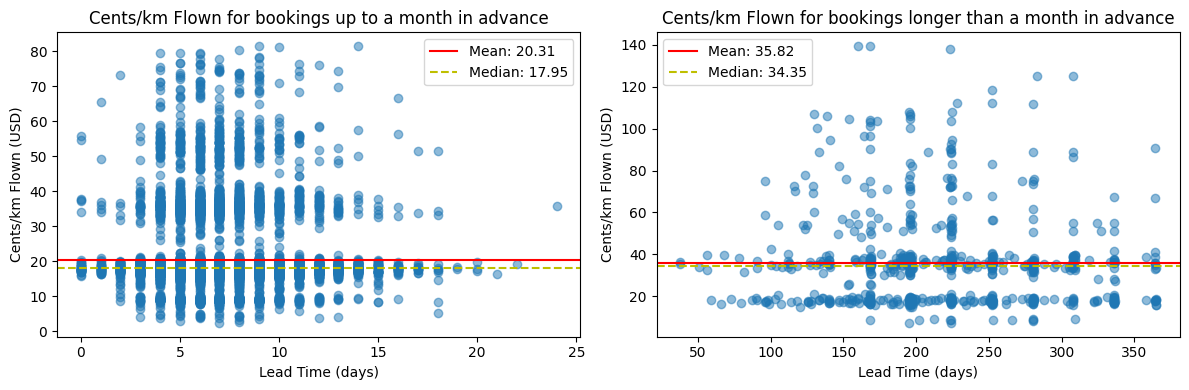

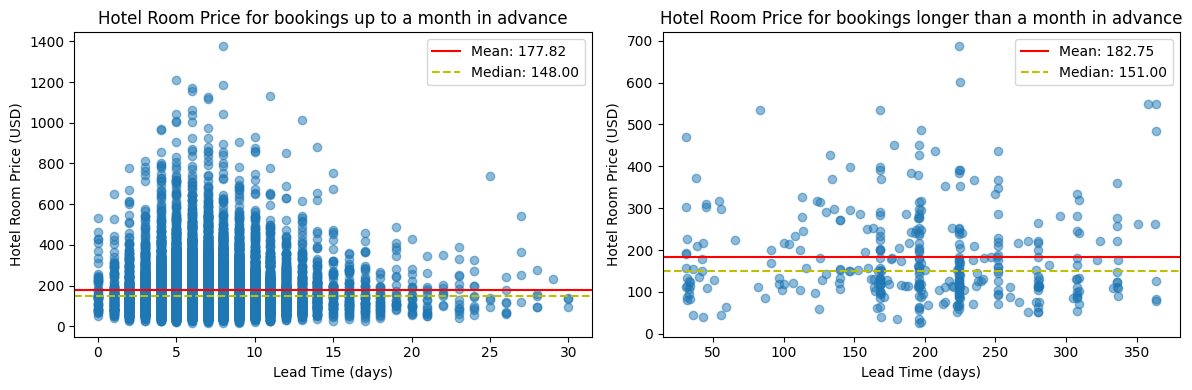

In [222]:
plot_leadtime_scatter('base_fare_usd', 'Base Flight Fare', 'USD')
plot_leadtime_scatter('cents_per_km_flown', 'Cents/km Flown', 'USD')
plot_leadtime_scatter('hotel_per_room_usd', 'Hotel Room Price', 'USD')

> Early planners pay significantly more for flights and a bit more for hotels

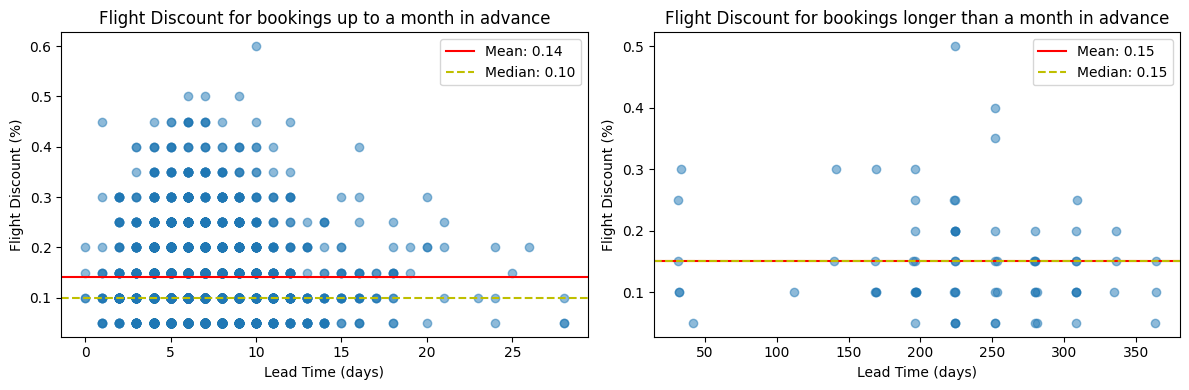

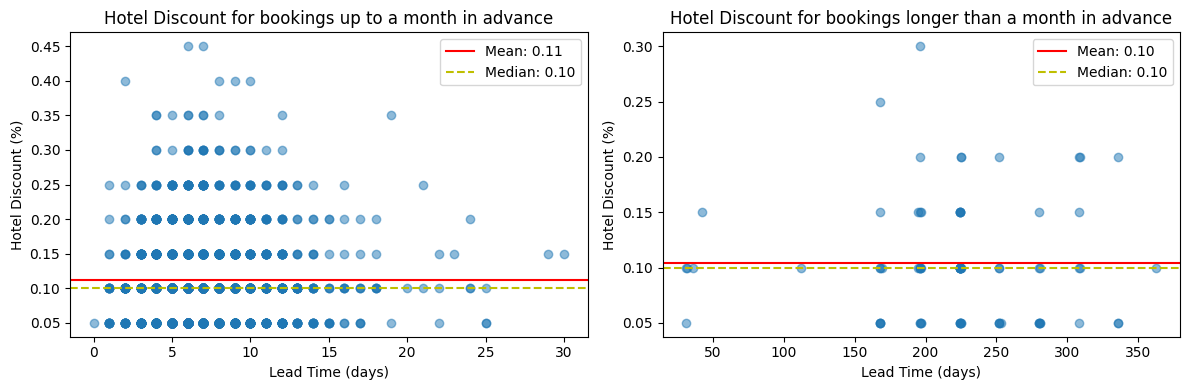

In [223]:
plot_leadtime_scatter('flight_discount_amount', 'Flight Discount', '%')
plot_leadtime_scatter('hotel_discount_amount', 'Hotel Discount', '%')

> We don't see a significant difference between discounts taken in early and last-minute bookings

## Time Series Trends: Bookings and Cancellations

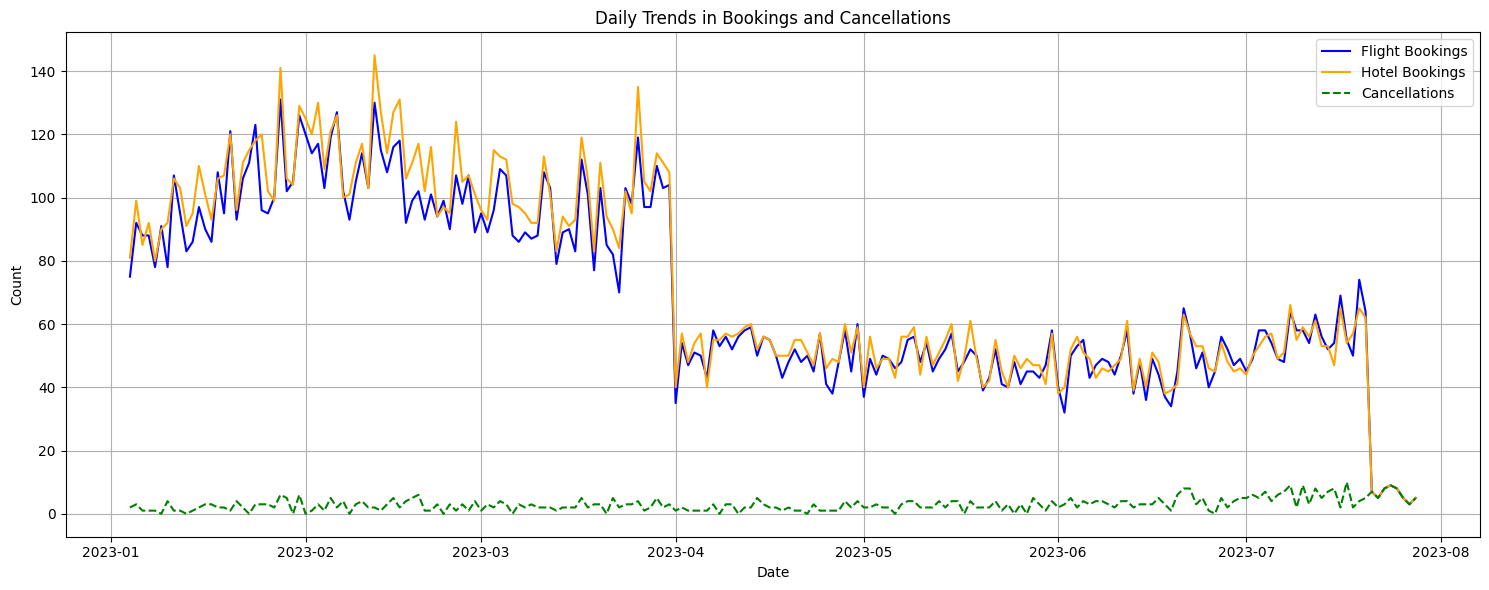

In [224]:
sessions['session_date'] = sessions['session_start'].dt.date
daily_bookings = sessions.groupby('session_date').agg(
    total_flight_bookings=('flight_booked', 'sum'),
    total_hotel_bookings=('hotel_booked', 'sum'),
    total_cancellations=('cancellation', 'sum')
).reset_index()

TimeSeriesPlot(
    title='Daily Trends in Bookings and Cancellations',
    date_column='session_date',
    lines=[
        TimeSeriesPlot.Line('total_flight_bookings', 'Flight Bookings', color='blue'),
        TimeSeriesPlot.Line('total_hotel_bookings', 'Hotel Bookings', color='orange'),
        TimeSeriesPlot.Line('total_cancellations', 'Cancellations', color='green', linestyle='--'),
    ],
    df=daily_bookings,
).plot()

> Here we see a signficant drop in bookigs by the begining of April and by the end of July